# FaceNet Inference Notebook
This notebook loads your trained `facenet_model.pth` and runs inference on new face images.

**Architecture detected:** Inception v1 (GoogLeNet) backbone → 128-d face embeddings  
**Input:** RGB images (any size — resized to 96×96 internally)  
**Output:** L2-normalized 128-dimensional embedding vector per face

## 1. Model Architecture Definition
Must match the architecture used during training (inferred from the state dict).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBn(nn.Module):
    """
    Conv -> BatchNorm block (no activation).
    Matches the state dict structure of the pre-trained FaceNet.
    """
    def __init__(self, in_c, out_c, kernel_size, stride=1, padding=0):
        super().__init__()
        # Define the convolutional layer and batch normalization sequentially
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size, stride=stride, padding=padding, bias=False),
            nn.BatchNorm2d(out_c, eps=0.001),
        )

    def forward(self, x):
        # Apply the sequential block and then pass through a ReLU activation
        return F.relu(self.block(x), inplace=True)


class InceptionModule(nn.Module):
    """Standard Inception module with 4 branches."""
    def __init__(self, in_c, b1, b2_r, b2, b3_r, b3, b4):
        super().__init__()
        # Branch 1: 1x1 convolution for dimensionality reduction
        self.branch1 = ConvBn(in_c, b1, 1)
        # Branch 2: 1x1 conv followed by a 3x3 conv
        self.branch2 = nn.Sequential(ConvBn(in_c, b2_r, 1), ConvBn(b2_r, b2, 3, padding=1))
        # Branch 3: 1x1 conv followed by a 5x5 conv
        self.branch3 = nn.Sequential(ConvBn(in_c, b3_r, 1), ConvBn(b3_r, b3, 5, padding=2))
        # Branch 4: 3x3 Max Pooling followed by a 1x1 conv
        self.branch4 = nn.Sequential(nn.MaxPool2d(3, stride=1, padding=1), ConvBn(in_c, b4, 1))

    def forward(self, x):
        # Concatenate the outputs of all 4 branches along the channel dimension (dim=1)
        return torch.cat([self.branch1(x), self.branch2(x), self.branch3(x), self.branch4(x)], 1)


class InceptionModuleStride(nn.Module):
    """Inception module with stride=2 (no branch1, no branch4 pool projection)."""
    def __init__(self, in_c, b2_r, b2, b3_r, b3):
        super().__init__()
        # Branch 2: 1x1 conv followed by a 3x3 conv with stride 2 (halves spatial dimensions)
        self.branch2 = nn.Sequential(ConvBn(in_c, b2_r, 1), ConvBn(b2_r, b2, 3, stride=2, padding=1))
        # Branch 3: 1x1 conv followed by a 5x5 conv with stride 2
        self.branch3 = nn.Sequential(ConvBn(in_c, b3_r, 1), ConvBn(b3_r, b3, 5, stride=2, padding=2))
        # Branch 4: 3x3 Max Pooling with stride 2
        self.branch4 = nn.MaxPool2d(3, stride=2, padding=1)

    def forward(self, x):
        # Concatenate outputs from the 3 branches to downsample spatial dimensions
        return torch.cat([self.branch2(x), self.branch3(x), self.branch4(x)], 1)


class FaceNet(nn.Module):
    """FaceNet with Inception v1 backbone -> 128-d L2-normalized embeddings."""
    def __init__(self):
        super().__init__()
        # Stem (Initial convolution and pooling layers for basic feature extraction)
        self.conv1  = ConvBn(3, 64, 7, stride=2, padding=3)        # Input to 48x48
        self.pool1  = nn.MaxPool2d(3, stride=2, padding=1)         # Downsample to 24x24
        self.conv2  = nn.Sequential(ConvBn(64, 64, 1), ConvBn(64, 192, 3, padding=1))
        self.pool2  = nn.MaxPool2d(3, stride=2, padding=1)         # Downsample to 12x12

        # Inception block 3
        self.inc3a  = InceptionModule(192, 64,  96, 128, 16,  32,  32)
        self.inc3b  = InceptionModule(256, 64,  96, 128, 32,  64,  64)
        self.inc3c  = InceptionModuleStride(320, 128, 256, 32, 64)  # Downsample to 6x6

        # Inception block 4
        self.inc4a  = InceptionModule(640, 256,  96, 192, 32,  64, 128)
        self.inc4b  = InceptionModule(640, 224, 112, 224, 32,  64, 128)
        self.inc4c  = InceptionModule(640, 192, 128, 256, 32,  64, 128)
        self.inc4d  = InceptionModule(640, 160, 144, 288, 32,  64, 128)
        self.inc4e  = InceptionModuleStride(640, 160, 256, 64, 128)  # Downsample to 3x3

        # Inception block 5
        self.inc5a  = InceptionModule(1024, 384, 192, 384, 48, 128, 128)
        self.inc5b  = InceptionModule(1024, 384, 192, 384, 48, 128, 128)

        # Final pooling, dropout, and fully connected embedding layer
        self.avgpool = nn.AdaptiveAvgPool2d(1)              # Global average pooling 
        self.dropout = nn.Dropout(p=0.4)                    # Prevent overfitting
        self.fc      = nn.Linear(1024, 128, bias=False)     # Project into 128-dimensional embedding space

    def forward(self, x):
        # Pass input through the network stages
        x = self.pool1(self.conv1(x))
        x = self.pool2(self.conv2(x))
        
        x = self.inc3a(x)
        x = self.inc3b(x)
        x = self.inc3c(x)
        
        x = self.inc4a(x)
        x = self.inc4b(x)
        x = self.inc4c(x)
        x = self.inc4d(x)
        x = self.inc4e(x)
        
        x = self.inc5a(x)
        x = self.inc5b(x)
        
        # Pool across spatial dimensions, flatten to 1D, and apply dropout
        x = self.dropout(self.avgpool(x).flatten(1))
        
        # Get raw 128-d embeddings
        x = self.fc(x)
        
        # L2-normalize vectors so they reside on a unit hypersphere (crucial for distance metrics)
        return F.normalize(x, p=2, dim=1)   

print("Model class defined.")

Model class defined.


## 2. Load the Trained Weights

In [3]:
MODEL_PATH = "/kaggle/input/datasets/shrek38/weights-model/facenet_model.pth"  # update the path 

# Select GPU if it is available, otherwise fallback to CPU computation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize the empty FaceNet model and move it to the targeted device
model = FaceNet().to(device)

# Load the pretrained weights dictionary mapping tensors to layers
state_dict = torch.load(MODEL_PATH, map_location=device, weights_only=False)

# Inject the weights into the initialized model architecture
model.load_state_dict(state_dict)

# Important: Set the model to evaluation mode (disables dropout, fixes batchnorm statistics)
model.eval()

print("✅ Model loaded successfully!")

# Calculate total number of trainable parameters in the model architecture
total_params = sum(p.numel() for p in model.parameters())
print(f"   Total parameters: {total_params:,}")

Using device: cpu
✅ Model loaded successfully!
   Total parameters: 7,464,096


## 3. Preprocessing Helper

In [4]:
from torchvision import transforms
from PIL import Image
import numpy as np

# Standard FaceNet image preprocessing pipeline
preprocess = transforms.Compose([
    transforms.Resize((96, 96)),          # Resize input image to the expected FaceNet size (96x96)
    transforms.ToTensor(),                # Convert PIL Image to PyTorch Tensor [0,255] -> [0.0, 1.0]
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],             # Normalize the pixel values across RGB channels
        std=[0.5, 0.5, 0.5]               # Results in standard values strictly between [-1.0, 1.0]
    ),
])


def get_embedding(image_path: str) -> np.ndarray:
    """
    Load an image and return its 128-d L2-normalized face embedding.
    
    Args:
        image_path: Path to a face image (jpg/png/etc.)
    Returns:
        numpy array of shape (128,)
    """
    # Open image and convert to RGB (necessary to handle grayscale or RGBA images correctly)
    img = Image.open(image_path).convert("RGB")
    
    # Preprocess image, add batch dimension to make it shape (1, 3, 96, 96), and move to device
    tensor = preprocess(img).unsqueeze(0).to(device)   
    
    # Run inference in no_grad mode to save memory as we aren't training
    with torch.no_grad():
        embedding = model(tensor)
        
    # Detach, move to CPU, grab the first element (the only batch element) and convert to numpy 
    return embedding.cpu().numpy()[0]


def get_embeddings_batch(image_paths: list) -> np.ndarray:
    """
    Get embeddings for a list of image paths in a single forward pass.
    
    Returns:
        numpy array of shape (N, 128)
    """
    # Create a list of preprocessed image tensors
    tensors = [preprocess(Image.open(p).convert("RGB")) for p in image_paths]
    
    # Stack the tensors into a single batch tensor of shape (N, 3, 96, 96) and push to device
    batch = torch.stack(tensors).to(device)
    
    # Calculate embeddings for the entire batch at once
    with torch.no_grad():
        embeddings = model(batch)
        
    # Return directly as a Numpy array
    return embeddings.cpu().numpy()

print("Preprocessing helpers ready.")

Preprocessing helpers ready.


## 4. Run Inference on a Single Image

Embedding shape : (128,)
Embedding norm  : 1.0000  (should be ~1.0)
Embedding (first 8 values): [-0.03708438 -0.06621233 -0.23839095 -0.07845391  0.13327575 -0.08886081
  0.04397858 -0.05663364]


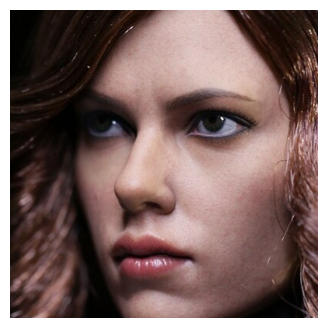

In [19]:
import matplotlib.pyplot as plt

def print_image(image_path, ax):
    img = Image.open(image_path).convert("RGB")
    ax.imshow(img)
    ax.axis("off")
    
# Change this to your image path 
IMAGE_PATH = "/kaggle/input/datasets/rishabhkmr/avengers-actors-images-dataset/Natasha_Romanoff (Scarlett Johansson)/Natasha_Romanoff1.png"

embedding = get_embedding(IMAGE_PATH)
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

print_image(IMAGE_PATH, ax)

print(f"Embedding shape : {embedding.shape}")
print(f"Embedding norm  : {np.linalg.norm(embedding):.4f}  (should be ~1.0)")
print(f"Embedding (first 8 values): {embedding[:8]}")

## 5. Face Verification — Are Two Images the Same Person?

Euclidean distance : 0.5250  (threshold = 0.6)
Cosine similarity  : 0.8622  (1.0 = identical, -1.0 = opposite)

✅ SAME PERSON


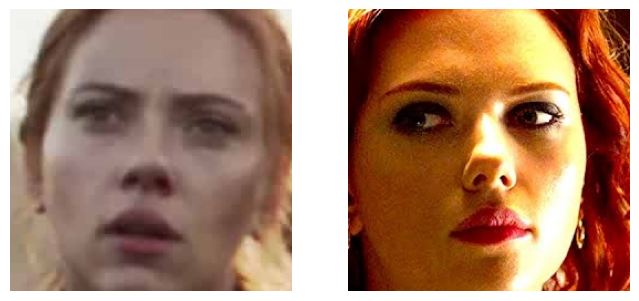

In [22]:
def euclidean_distance(emb1: np.ndarray, emb2: np.ndarray) -> float:
    return float(np.linalg.norm(emb1 - emb2))

def cosine_similarity(emb1: np.ndarray, emb2: np.ndarray) -> float:
    return float(np.dot(emb1, emb2))   # embeddings are already L2-normalised


# Change these paths 
IMAGE_A = "/kaggle/input/datasets/rishabhkmr/avengers-actors-images-dataset/Natasha_Romanoff (Scarlett Johansson)/Natasha_Romanoff103.png"
IMAGE_B = "/kaggle/input/datasets/rishabhkmr/avengers-actors-images-dataset/Natasha_Romanoff (Scarlett Johansson)/Natasha_Romanoff102.png"

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

print_image(IMAGE_A, axes[0])
print_image(IMAGE_B, axes[1])

# Typical threshold for FaceNet: L2 distance < 1.0 → same person
THRESHOLD = 0.6

emb_a = get_embedding(IMAGE_A)
emb_b = get_embedding(IMAGE_B)

dist = euclidean_distance(emb_a, emb_b)
sim  = cosine_similarity(emb_a, emb_b)

print(f"Euclidean distance : {dist:.4f}  (threshold = {THRESHOLD})")
print(f"Cosine similarity  : {sim:.4f}  (1.0 = identical, -1.0 = opposite)")
print()

if dist < THRESHOLD:
    print("✅ SAME PERSON")
else:
    print("❌ DIFFERENT PEOPLE")